<a href="https://colab.research.google.com/github/pranavKarthikCu/Facial-Emotion-Recognition-using-Deep-Learning/blob/main/FER_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import drive
import os

drive.mount('/content/drive')

# Define paths for saving the best model weights
GDRIVE_PATH = '/content/drive/MyDrive/fer2013_models' # Adjust this folder name as needed
DRIVE_CHECKPOINT_PATH = os.path.join(GDRIVE_PATH, 'fer2013_best_model_2.h5')

# Create the folder if it doesn't exist
os.makedirs(GDRIVE_PATH, exist_ok=True)
print(f"Model checkpoint path set to: {DRIVE_CHECKPOINT_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model checkpoint path set to: /content/drive/MyDrive/fer2013_models/fer2013_best_model_2.h5


In [ ]:
#Importing required libraries
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset, Image
from sklearn.utils import class_weight
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
REPO_ID = "AutumnQiu/fer2013" # The Hugging Face dataset identifier
IMG_SIZE = (48, 48)
BATCH_SIZE = 64
NUM_CLASSES = 7
EPOCHS = 50
# You will set the patience for Early Stopping later

# Ensure GPU is available (optional but highly recommended)
print(f"TensorFlow Version: {tf.__version__}")
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: []


In [ ]:
# Load the raw dataset
# This downloads and caches the data locally, bypassing Google Drive I/O
print(f"Loading dataset: {REPO_ID}")
raw_datasets = load_dataset(REPO_ID)
class_names = raw_datasets["train"].features["label"].names
print("Class Names:", class_names)

def preprocess_function(example):
    """Converts Hugging Face image objects into a rescaled TF tensor."""
    # Convert PIL Image object to NumPy array (grayscale)
    image_array = np.array(example['image'].convert('L'))

    # Add channel dimension: (48, 48) -> (48, 48, 1)
    image_tensor = tf.expand_dims(image_array, axis=-1)

    # Rescale pixels from 0-255 to 0.0-1.0
    image_tensor = tf.cast(image_tensor, tf.float32) / 255.0

    # Convert integer label to one-hot encoding
    label_tensor = tf.one_hot(example['label'], depth=NUM_CLASSES)

    # Return a dictionary format compatible with the map function
    return {"image": image_tensor, "label": label_tensor}

Loading dataset: AutumnQiu/fer2013
Class Names: ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']


In [ ]:
# Apply preprocessing and convert to tf.data.Dataset
def to_tf_dataset(split_ds, shuffle=False):
    ds = split_ds.select_columns(['image', 'label']).to_tf_dataset(
        columns='image',          # Input (X)
        label_cols='label',       # Output (Y)
        batch_size=BATCH_SIZE,
        shuffle=shuffle
    ).cache().prefetch(tf.data.AUTOTUNE)
    return ds

# Apply preprocessing
processed_datasets = raw_datasets.map(preprocess_function, batched=False)

# Convert the processed datasets into the final, optimized TF objects
train_ds = to_tf_dataset(processed_datasets["train"], shuffle=True)
test_ds = to_tf_dataset(processed_datasets["test"], shuffle=False)


Train Class Counts: {'Angry': 3995, 'Disgust': 436, 'Fear': 4097, 'Happy': 7215, 'Sad': 4830, 'Surprise': 3171, 'Neutral': 4965}

Computed Class Weights (Index: Weight):
  Angry: 1.01
  Disgust: 3.07
  Fear: 1.00
  Happy: 0.75
  Sad: 0.92
  Surprise: 1.14
  Neutral: 0.91


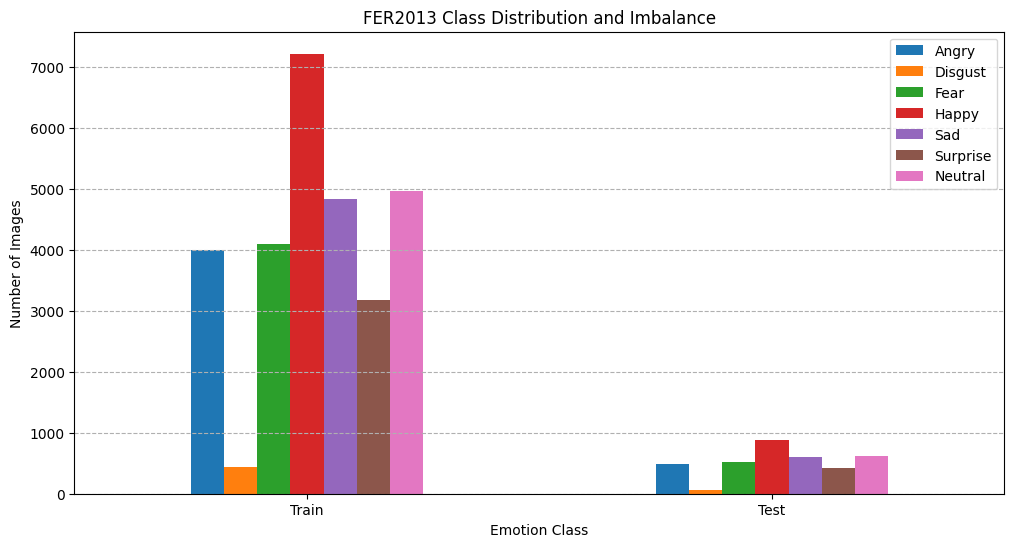

In [ ]:
# Calculate counts for Class Weighting
train_labels_int = raw_datasets["train"]["label"]
train_counts_series = pd.Series(train_labels_int).value_counts().sort_index()

# Map the counts to class names for plotting
train_counts = {class_names[i]: count for i, count in train_counts_series.items()}
print("\nTrain Class Counts:", train_counts)

# Calculate Class Weights
# These weights penalize the model more for misclassifying rare classes (e.g., Disgust)
class_weights_array = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_labels_int),
    y=train_labels_int
)
dampened_weights = np.sqrt(class_weights_array)

class_weight_dict = dict(enumerate(dampened_weights))

print("\nComputed Class Weights (Index: Weight):")
for i, weight in class_weight_dict.items():
    print(f"  {class_names[i]}: {weight:.2f}")

# Visualize the imbalance
test_labels_int = raw_datasets["test"]["label"]
test_counts_series = pd.Series(test_labels_int).value_counts().sort_index()
test_counts = {class_names[i]: count for i, count in test_counts_series.items()}

data = pd.DataFrame({'Train': train_counts, 'Test': test_counts}).T
data.plot(kind='bar', figsize=(12, 6), rot=0)
plt.title('FER2013 Class Distribution and Imbalance')
plt.ylabel('Number of Images')
plt.xlabel('Emotion Class')
plt.grid(axis='y', linestyle='--')
plt.show()

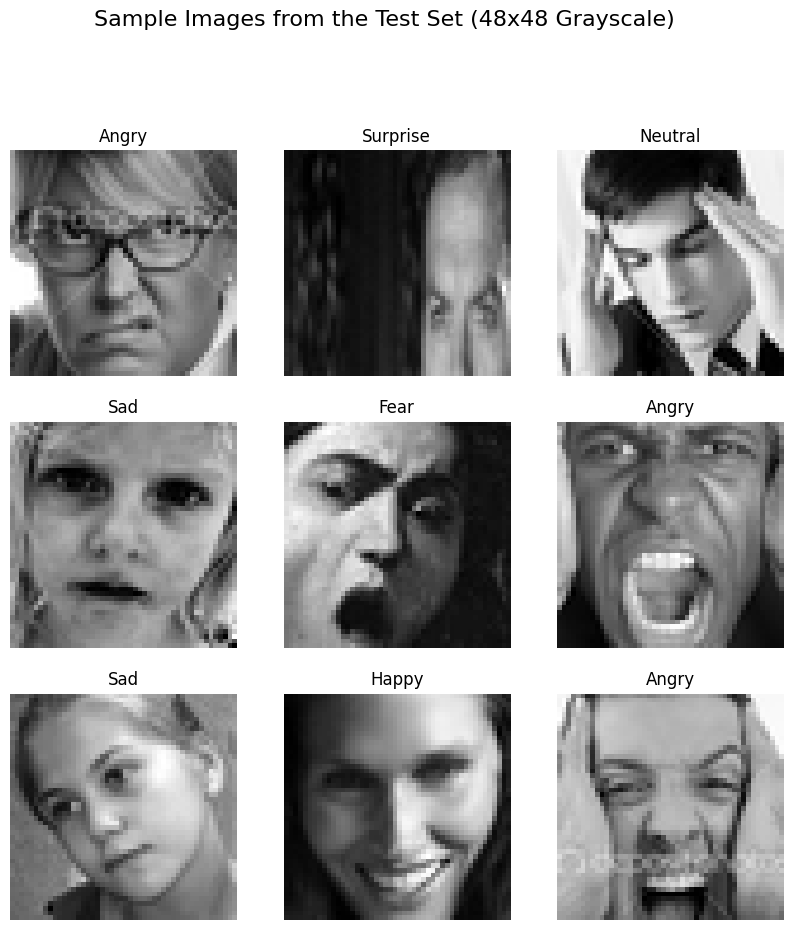

In [ ]:
def plot_sample_images(dataset, class_names):
    """Plots a grid of sample images with their labels."""
    plt.figure(figsize=(10, 10))

    # Grab one batch from the dataset iterator
    for images, labels in dataset.take(1):
        # We only need the first 9 images for the grid
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)

            # The images are (48, 48, 1) and need to be squeezed to (48, 48) for display
            # They are already normalized (0-1), so we display them as grayscale
            plt.imshow(images[i].numpy().squeeze(), cmap='gray')

            # Get the true class name from the one-hot label
            true_label_index = np.argmax(labels[i].numpy())
            plt.title(class_names[true_label_index])
            plt.axis("off")

        break # Exit after the first batch

plot_sample_images(test_ds, class_names)
plt.suptitle('Sample Images from the Test Set (48x48 Grayscale)', fontsize=16, y=1.02)
plt.show()

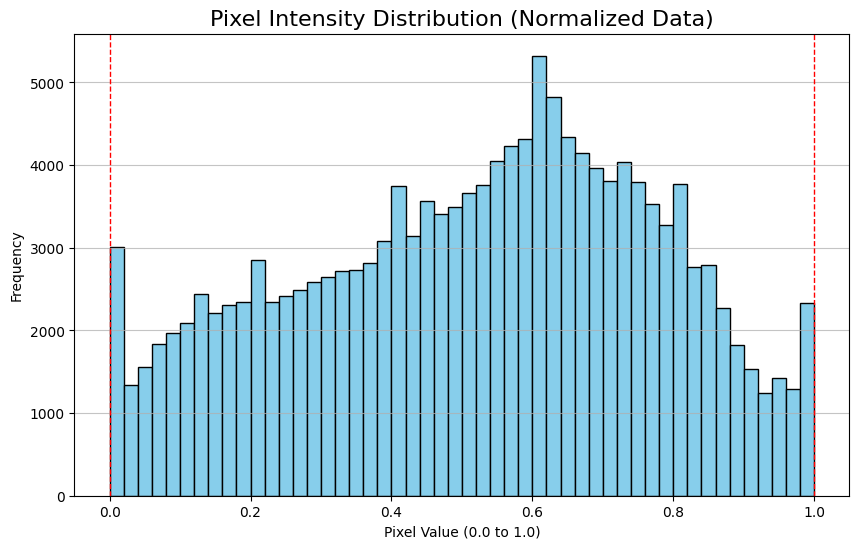

In [ ]:
def plot_pixel_intensity_histogram(dataset):
    """Calculates and plots the histogram of pixel values."""

    # 1. Grab a single batch (large enough to be representative)
    # Using the train_ds for this check
    for images, _ in dataset.take(1):
        # Convert the batch of images into a single 1D array of all pixel values
        pixel_values = images.numpy().flatten()
        break

    # 2. Plot the histogram
    plt.figure(figsize=(10, 6))
    plt.hist(pixel_values, bins=50, color='skyblue', edgecolor='black', range=[0, 1])
    plt.title('Pixel Intensity Distribution (Normalized Data)', fontsize=16)
    plt.xlabel('Pixel Value (0.0 to 1.0)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)

    # Add vertical lines to show the expected range
    plt.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.axvline(1, color='red', linestyle='--', linewidth=1)
    plt.show()

plot_pixel_intensity_histogram(train_ds)

In [ ]:
# Data Augmentation Layer
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# CNN Model Definition
#
model = models.Sequential([
    # Input shape: 48x48 grayscale (1 channel)
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(48, 48, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    # Block 4
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    # Classifier Head
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Compile the model
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#model.summary()


# Callbacks
DRIVE_CHECKPOINT_PATH = os.path.join(GDRIVE_PATH, 'fer2013_best_model_2.keras')

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',   # Watch the validation loss
    factor=0.5,           # Cut learning rate in half
    patience=3,           # If no improvement for 3 epochs
    min_lr=1e-6,          # Don't go below this
    verbose=1             # Print a message when it happens
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ModelCheckpoint(
        filepath=DRIVE_CHECKPOINT_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    ),
    lr_scheduler
]

# Train the model
print("\nStarting Training...")
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

#Final Evaluation
print("\nFinal Evaluation:")
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")



Starting Training...
Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 306s 674ms/step - accuracy: 0.2112 - loss: 2.2663 - val_accuracy: 0.1931 - val_loss: 1.8639 - learning_rate: 0.0010
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - accuracy: 0.2550 - loss: 1.7856 - val_accuracy: 0.2477 - val_loss: 1.8359 - learning_rate: 0.0010
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - accuracy: 0.2992 - loss: 1.7249 - val_accuracy: 0.2761 - val_loss: 1.7480 - learning_rate: 0.0010
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - accuracy: 0.3402 - loss: 1.6497 - val_accuracy: 0.4232 - val_loss: 1.4738 - learning_rate: 0.0010
Epoch 5/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - accuracy: 0.3728 - loss: 1.6002 - val_accuracy: 0.4152 - val_loss: 1.5232 - learning_rate: 0.0010
Epoch 6/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - accuracy: 0.3979 - loss: 1.5453 - val_accuracy: 0.4397 - val_loss: 1.4333 - learning_rate: 0.0010
Epoch 7/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/ste

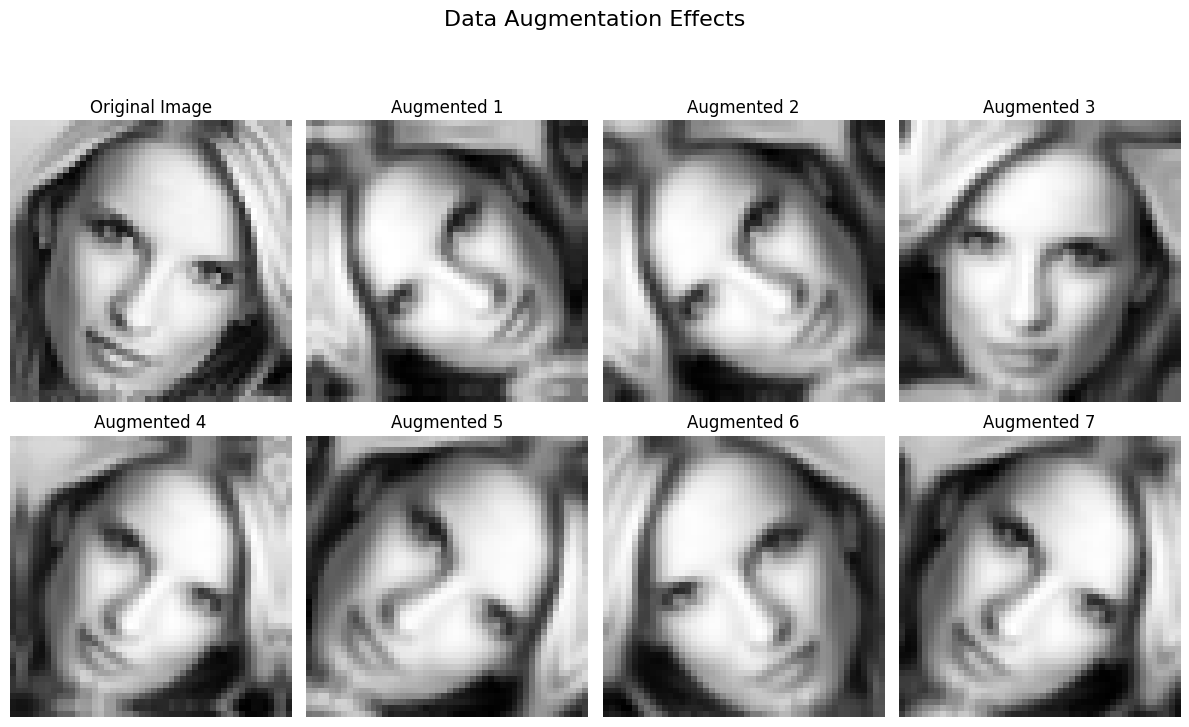

In [ ]:
import matplotlib.pyplot as plt

# Get one batch of images from the training dataset
for images, _ in train_ds.take(1):
    # Take the first image from the batch
    sample_image = images[0]
    break

# Prepare to plot the original and augmented images
plt.figure(figsize=(12, 8))

# Plot the original image
plt.subplot(2, 4, 1)
plt.imshow(sample_image.numpy().squeeze(), cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Apply data augmentation and plot several augmented versions
for i in range(7):
    augmented_image = data_augmentation(tf.expand_dims(sample_image, 0))
    plt.subplot(2, 4, i + 2)
    plt.imshow(augmented_image[0].numpy().squeeze(), cmap='gray')
    plt.title(f'Augmented {i+1}')
    plt.axis('off')

plt.suptitle('Data Augmentation Effects', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
print("Generating predictions on the test set...")
# Predict probabilities for all samples in the test dataset
y_pred_probs = model.predict(test_ds)

# Get the predicted class indices (the index with the highest probability)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Get the true labels from the test dataset
y_true_labels_onehot = []
for _, labels in test_ds:
    y_true_labels_onehot.append(labels.numpy())

# Concatenate and convert from one-hot back to integer indices
y_true_labels_onehot = np.concatenate(y_true_labels_onehot, axis=0)
y_true_classes = np.argmax(y_true_labels_onehot, axis=1)

# Ensure the lengths match before generating metrics
if len(y_true_classes) != len(y_pred_classes):
    print("ERROR: Lengths of true labels and predictions do not match!")
    # This might happen if there are incomplete batches, but it's rare with the Hugging Face setup.
    # We proceed assuming they match based on the error-free training.

Generating predictions on the test set...
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [ ]:
# Display the keys available in the history object
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


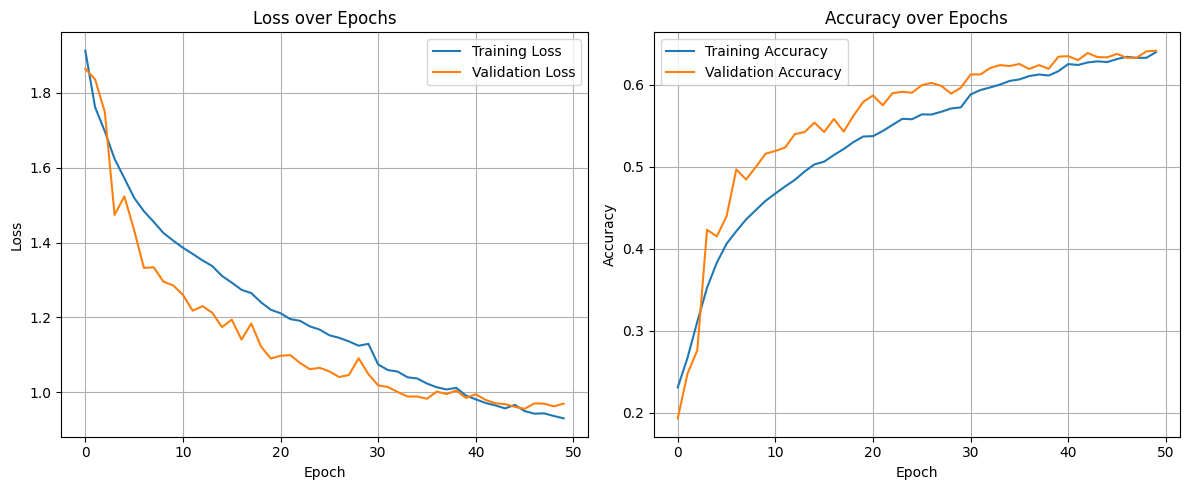

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training and validation accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:

# Generate the classification report
report = classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=class_names,
    digits=4
)
print(report)

              precision    recall  f1-score   support

       Angry     0.5743    0.5743    0.5743       491
     Disgust     0.5370    0.5273    0.5321        55
        Fear     0.5289    0.3466    0.4188       528
       Happy     0.8826    0.8385    0.8600       879
         Sad     0.4826    0.4916    0.4871       594
    Surprise     0.7134    0.7957    0.7523       416
     Neutral     0.5655    0.7173    0.6324       626

    accuracy                         0.6417      3589
   macro avg     0.6121    0.6130    0.6081      3589
weighted avg     0.6420    0.6417    0.6371      3589



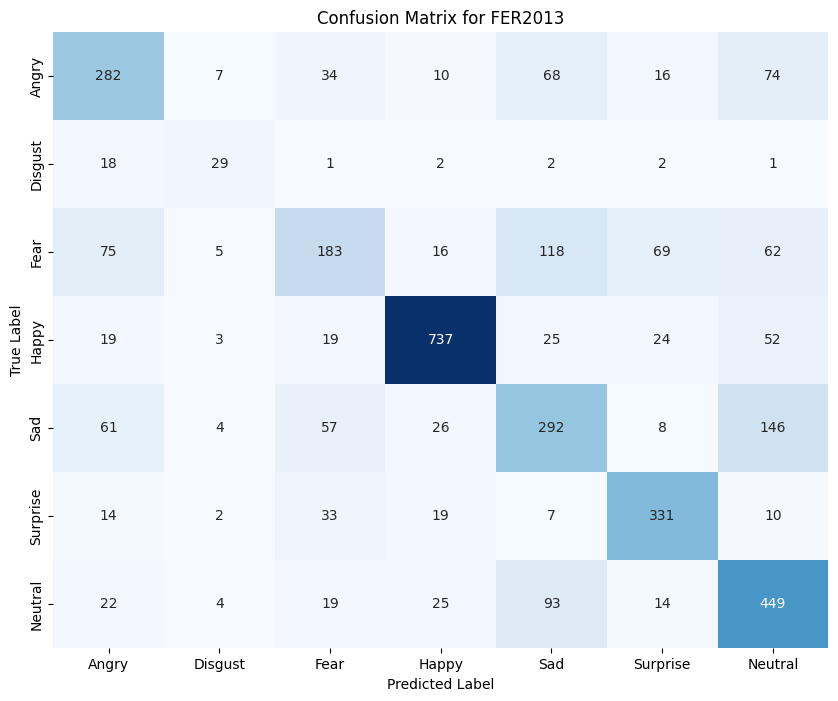

In [ ]:
# Calculate the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for FER2013')
plt.show()

/tmp/ipython-input-4187396769.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Accuracy', data=accuracy_df, palette='viridis')


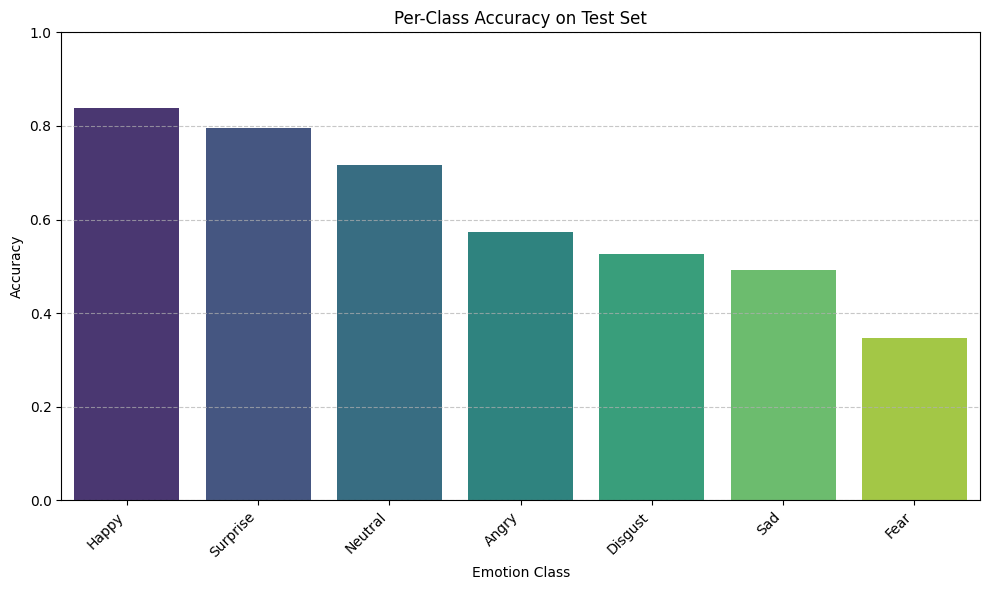

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Generate the classification report
report_dict = classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=class_names,
    output_dict=True
)

# Extract per-class accuracy (recall)
class_accuracies = {class_name: report_dict[class_name]['recall'] for class_name in class_names}

# Convert to DataFrame for easier plotting with seaborn
accuracy_df = pd.DataFrame(class_accuracies.items(), columns=['Class', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

# Plotting the per-class accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Per-Class Accuracy on Test Set')
plt.xlabel('Emotion Class')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy ranges from 0 to 1
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Get one batch of images and labels from the test dataset
all_images = []
all_true_labels = []

for images, labels in test_ds:
    all_images.append(images.numpy())
    all_true_labels.append(np.argmax(labels.numpy(), axis=1))

all_images = np.concatenate(all_images, axis=0)
all_true_labels = np.concatenate(all_true_labels, axis=0)

# Filter correctly and incorrectly classified images
correct_indices = np.where(y_true_classes == y_pred_classes)[0]
incorrect_indices = np.where(y_true_classes != y_pred_classes)[0]

print(f"Total test samples: {len(y_true_classes)}")
print(f"Correctly classified: {len(correct_indices)}")
print(f"Incorrectly classified: {len(incorrect_indices)}")

Total test samples: 3589
Correctly classified: 2303
Incorrectly classified: 1286


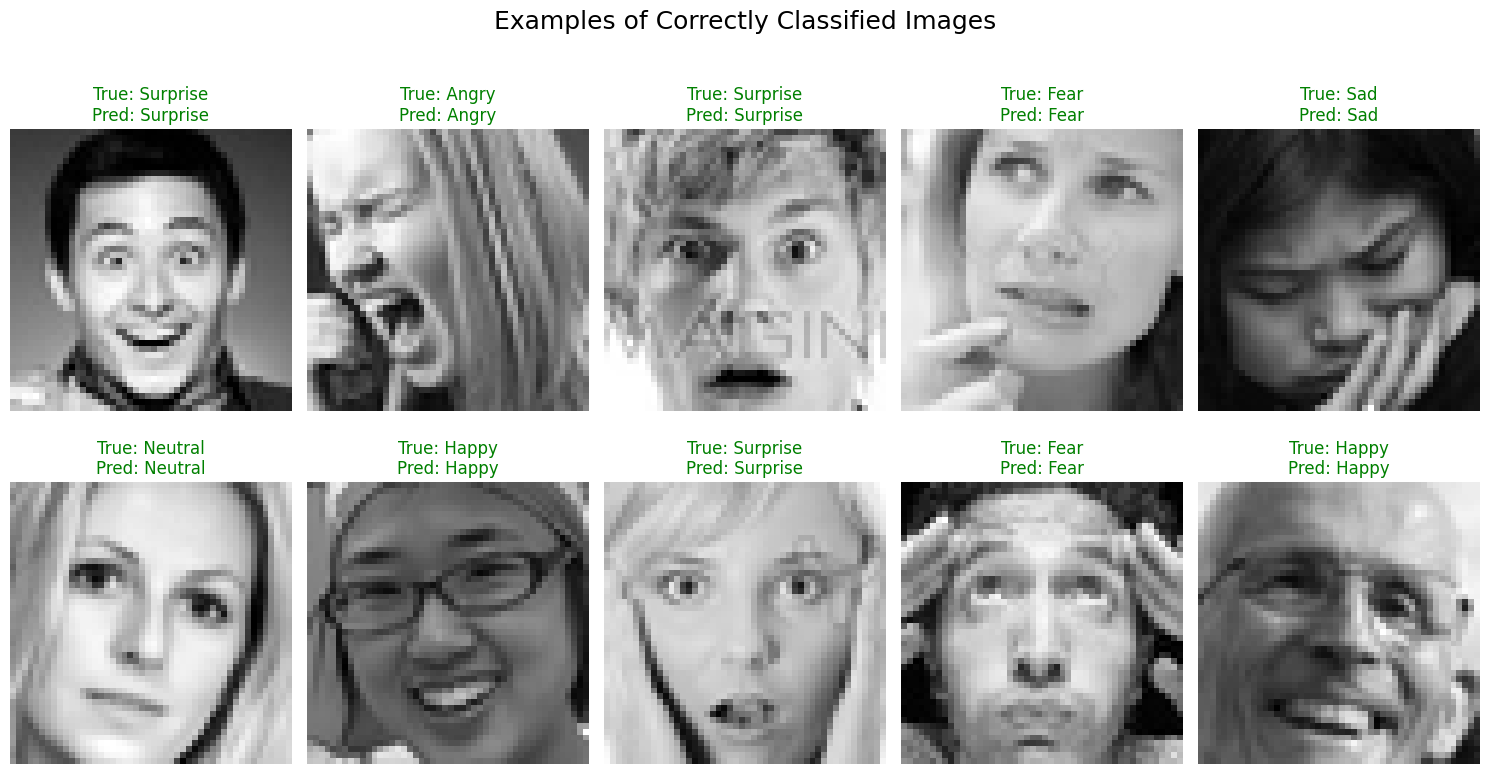

In [ ]:
import matplotlib.pyplot as plt

# --- Plotting Correctly Classified Examples ---
plt.figure(figsize=(15, 8))
plt.suptitle('Examples of Correctly Classified Images', fontsize=18, y=1.02)

# Select up to 10 random correct examples
num_correct_to_plot = min(10, len(correct_indices))
selected_correct_indices = np.random.choice(correct_indices, num_correct_to_plot, replace=False)

for i, idx in enumerate(selected_correct_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(all_images[idx].squeeze(), cmap='gray')
    true_label = class_names[all_true_labels[idx]]
    predicted_label = class_names[y_pred_classes[idx]]
    plt.title(f"True: {true_label}\nPred: {predicted_label}", color='green')
    plt.axis('off')

plt.tight_layout()
plt.show()

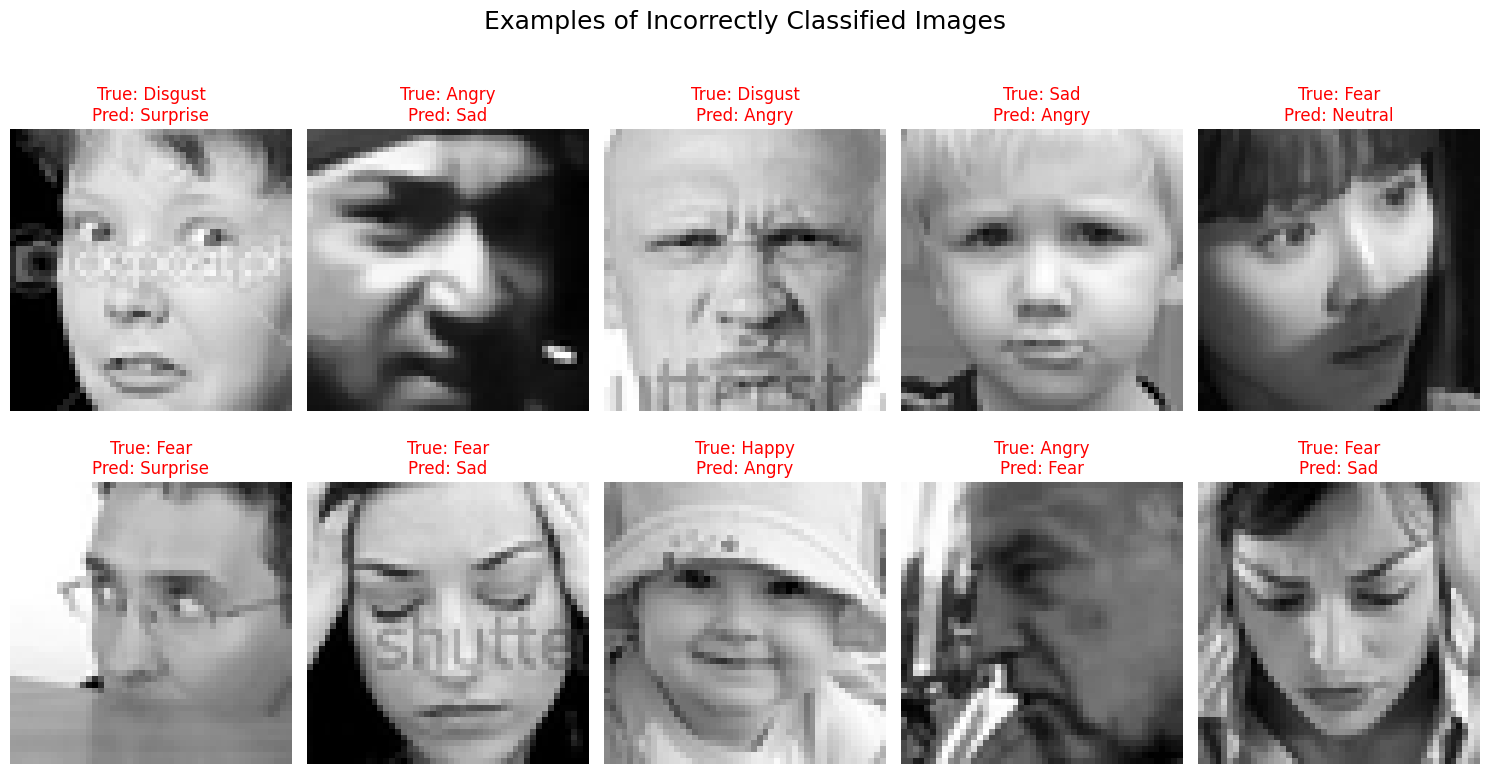

In [ ]:
import matplotlib.pyplot as plt

# --- Plotting Incorrectly Classified Examples ---
plt.figure(figsize=(15, 8))
plt.suptitle('Examples of Incorrectly Classified Images', fontsize=18, y=1.02)

# Select up to 10 random incorrect examples
num_incorrect_to_plot = min(10, len(incorrect_indices))
selected_incorrect_indices = np.random.choice(incorrect_indices, num_incorrect_to_plot, replace=False)

for i, idx in enumerate(selected_incorrect_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(all_images[idx].squeeze(), cmap='gray')
    true_label = class_names[all_true_labels[idx]]
    predicted_label = class_names[y_pred_classes[idx]]
    plt.title(f"True: {true_label}\nPred: {predicted_label}", color='red')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Save the final model
FINAL_MODEL_PATH = os.path.join(GDRIVE_PATH, 'fer2013_final_model_2.keras')

# Use the recommended Keras native format (.keras) to avoid the HDF5 warning
model.save(FINAL_MODEL_PATH)
print(f"Final model successfully saved to: {FINAL_MODEL_PATH}")

Final model successfully saved to: /content/drive/MyDrive/fer2013_models/fer2013_final_model_2.keras
